In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'Holt_Winters'

# Holt-Winters — 02: Walk-Forward Validation
**Grupo 1 | Séries Temporais**

Implementação do protocolo **walk-forward** para o modelo Holt-Winters (Exponential Smoothing).  

O walk-forward simula o uso real do modelo: a cada passo, o modelo é treinado com todos os dados históricos disponíveis até aquele momento, produz uma previsão para o dia seguinte, e a observação real é incorporada antes do passo seguinte.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import time
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70
np.random.seed(RANDOM_STATE)

## 1. Carregamento dos Dados e Configuração

In [3]:
# Dados
df = pd.read_csv(DATA_DIR / 'bitcoin_limpo.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

n        = len(df)
n_train  = int(n * TRAIN_RATIO)
n_test   = n - n_train
data_corte = df.iloc[n_train]['date']

serie_completa = df.set_index('date')['priceClose']
serie_train    = serie_completa.iloc[:n_train]
serie_test     = serie_completa.iloc[n_train:]

print(f'Total: {n}  |  Treino: {n_train}  |  Teste: {n_test}')
print(f'Corte: {data_corte.date()}')

Total: 2943  |  Treino: 2060  |  Teste: 883
Corte: 2024-04-12


In [4]:
# Carregar configuração selecionada no notebook anterior
with open(OUTPUT_DIR / 'hw_config_final.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

HW_PARAMS = {
    'trend':            config['trend'],
    'seasonal':         config['seasonal'],
    'seasonal_periods': config['seasonal_periods'],
    'damped_trend':     config['damped_trend']
}

print('=== Configuracao carregada ===')
for k, v in HW_PARAMS.items():
    print(f'  {k}: {v}')
print(f'  MAE_CV (selecao): {config["mae_cv"]:,.2f}')
print(f'  AIC              : {config["aic"]:.2f}')

=== Configuracao carregada ===
  trend: mul
  seasonal: None
  seasonal_periods: None
  damped_trend: False
  MAE_CV (selecao): 8,899.72
  AIC              : 28719.21


## 2. Protocolo Walk-Forward

```
Janela inicial de treino: n_train observações (70% dos dados)

Para cada dia t no conjunto de teste (n_test = 883 dias):
  1. Treinar Holt-Winters em todo o histórico até t-1
  2. Prever priceClose de t (1 passo à frente)
  3. Registrar (data_t, valor_real_t, previsão_t)
  4. Incorporar valor_real_t ao histórico → avançar t
```

> **Hiperparâmetros fixos:** A estrutura do modelo (trend, seasonal, periods, damped) é mantida constante durante todo o walk-forward — os parâmetros de suavização (α, β, γ) são re-estimados por MLE a cada refitting.

In [5]:
def walk_forward_hw(serie, n_train, hw_params, verbose_step=100):
    """
    Executa validação walk-forward 1-passo-à-frente para Holt-Winters.

    Parameters
    ----------
    serie       : pd.Series com índice de datas (série completa)
    n_train     : int, tamanho da janela inicial de treino
    hw_params   : dict com parâmetros estruturais do HW
    verbose_step: int, a cada quantos passos imprimir progresso

    Returns
    -------
    df_preds    : pd.DataFrame com colunas [date, y_real, y_pred, residuo]
    tempos      : list de tempos de ajuste por passo
    """
    n_total = len(serie)
    n_test  = n_total - n_train
    datas   = serie.index
    valores = serie.values

    previsoes = []
    reais     = []
    datas_test = []
    tempos    = []

    print(f'Walk-forward: {n_test} passos | Janela inicial: {n_train} obs')
    print(f'Hiperparametros fixos: {hw_params}')
    print('-' * 70)

    t0_total = time.time()

    for i in range(n_test):
        t0 = time.time()

        # Janela de treino expandida (expanding window)
        janela_treino = pd.Series(valores[:n_train + i], index=datas[:n_train + i])
        data_alvo     = datas[n_train + i]
        valor_real    = valores[n_train + i]

        try:
            model = ExponentialSmoothing(
                janela_treino,
                trend=hw_params['trend'],
                seasonal=hw_params['seasonal'],
                seasonal_periods=hw_params['seasonal_periods'],
                damped_trend=hw_params['damped_trend']
            )
            fit = model.fit(optimized=True, remove_bias=True)
            previsao = float(fit.forecast(1).iloc[0])
        except Exception as e:
            # Fallback: usar último valor observado (naive)
            previsao = float(janela_treino.iloc[-1])

        previsoes.append(previsao)
        reais.append(float(valor_real))
        datas_test.append(data_alvo)
        tempos.append(time.time() - t0)

        if (i + 1) % verbose_step == 0 or i == 0:
            mae_parcial = mean_absolute_error(reais, previsoes)
            elapsed = time.time() - t0_total
            eta = elapsed / (i + 1) * (n_test - i - 1)
            print(f'  Passo {i+1:4d}/{n_test} | MAE parcial: {mae_parcial:,.2f} | '
                  f'Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s')

    total_elapsed = time.time() - t0_total
    print(f'\nConcluido em {total_elapsed:.1f}s  |  Média por passo: {np.mean(tempos)*1000:.0f}ms')

    df_preds = pd.DataFrame({
        'date':    datas_test,
        'y_real':  reais,
        'y_pred':  previsoes,
        'residuo': [r - p for r, p in zip(reais, previsoes)]
    })

    return df_preds, tempos

In [6]:
# Executar walk-forward
df_preds, tempos_fit = walk_forward_hw(
    serie=serie_completa,
    n_train=n_train,
    hw_params=HW_PARAMS,
    verbose_step=150
)

Walk-forward: 883 passos | Janela inicial: 2060 obs
Hiperparametros fixos: {'trend': 'mul', 'seasonal': None, 'seasonal_periods': None, 'damped_trend': False}
----------------------------------------------------------------------
  Passo    1/883 | MAE parcial: 3,229.87 | Elapsed: 0s | ETA: 88s


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: Value

  Passo  150/883 | MAE parcial: 1,266.17 | Elapsed: 20s | ETA: 96s


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: Value

  Passo  300/883 | MAE parcial: 1,432.07 | Elapsed: 38s | ETA: 75s


...

C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: Value

  Passo  750/883 | MAE parcial: 1,483.09 | Elapsed: 101s | ETA: 18s


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: Co


Concluido em 123.3s  |  Média por passo: 140ms


C:\Users\raqueltolomei-ieg\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 3. Métricas de Desempenho

In [7]:
mae   = mean_absolute_error(df_preds['y_real'], df_preds['y_pred'])
rmse  = float(np.sqrt(np.mean(df_preds['residuo']**2)))
mape  = float(np.mean(np.abs(df_preds['residuo'] / df_preds['y_real'])) * 100)
bias  = float(df_preds['residuo'].mean())
std_r = float(df_preds['residuo'].std())

print('=== Metricas Walk-Forward — Holt-Winters ===')
print(f'  MAE  : {mae:,.2f} USD   <- metrica principal')
print(f'  RMSE : {rmse:,.2f} USD')
print(f'  MAPE : {mape:.2f} %')
print(f'  Bias : {bias:,.2f} USD  (pos=subestima, neg=superestima)')
print(f'  StdR : {std_r:,.2f} USD  (desvio padrao dos residuos)')
print(f'  N    : {len(df_preds)} previsoes')

# Métricas por semestre (para ver estabilidade ao longo do tempo)
df_preds['date_dt'] = pd.to_datetime(df_preds['date'])
df_preds['semestre'] = df_preds['date_dt'].dt.to_period('6M').astype(str)
metrics_semestre = df_preds.groupby('semestre').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g['y_real'], g['y_pred']),
        'Bias': g['residuo'].mean(),
        'N': len(g)
    })
).round(2)
print()
print('=== MAE por Semestre ===')
print(metrics_semestre.to_string())

=== Metricas Walk-Forward — Holt-Winters ===
  MAE  : 1,407.98 USD   <- metrica principal
  RMSE : 1,960.64 USD
  MAPE : 1.72 %
  Bias : -11.90 USD  (pos=subestima, neg=superestima)
  StdR : 1,961.71 USD  (desvio padrao dos residuos)
  N    : 883 previsoes

=== MAE por Semestre ===
              MAE    Bias     N
semestre                       
2024-04   1446.49 -665.76  19.0
2024-05   1368.47  139.17  31.0
2024-06    848.50 -215.21  30.0
2024-07   1206.46  107.29  31.0
2024-08   1511.09 -123.21  31.0
2024-09   1098.86  196.57  30.0
2024-10   1060.51  165.94  31.0
2024-11   1969.04  424.00  30.0
2024-12   1843.60 -586.31  31.0
2025-01   1744.50   42.91  31.0
2025-02   1478.72 -714.55  28.0
2025-03   2179.80   89.37  31.0
2025-04   1632.76  468.10  30.0
2025-05   1401.44   59.65  31.0
2025-06   1245.98  -77.49  30.0
2025-07   1227.30   34.27  31.0
2025-08   1709.49 -367.85  31.0
2025-09   1084.43  205.04  30.0
2025-10   2090.16 -161.40  31.0
2025-11   1854.45 -364.35  30.0
2025-12   126

## 4. Visualização: Previsões vs Valores Reais

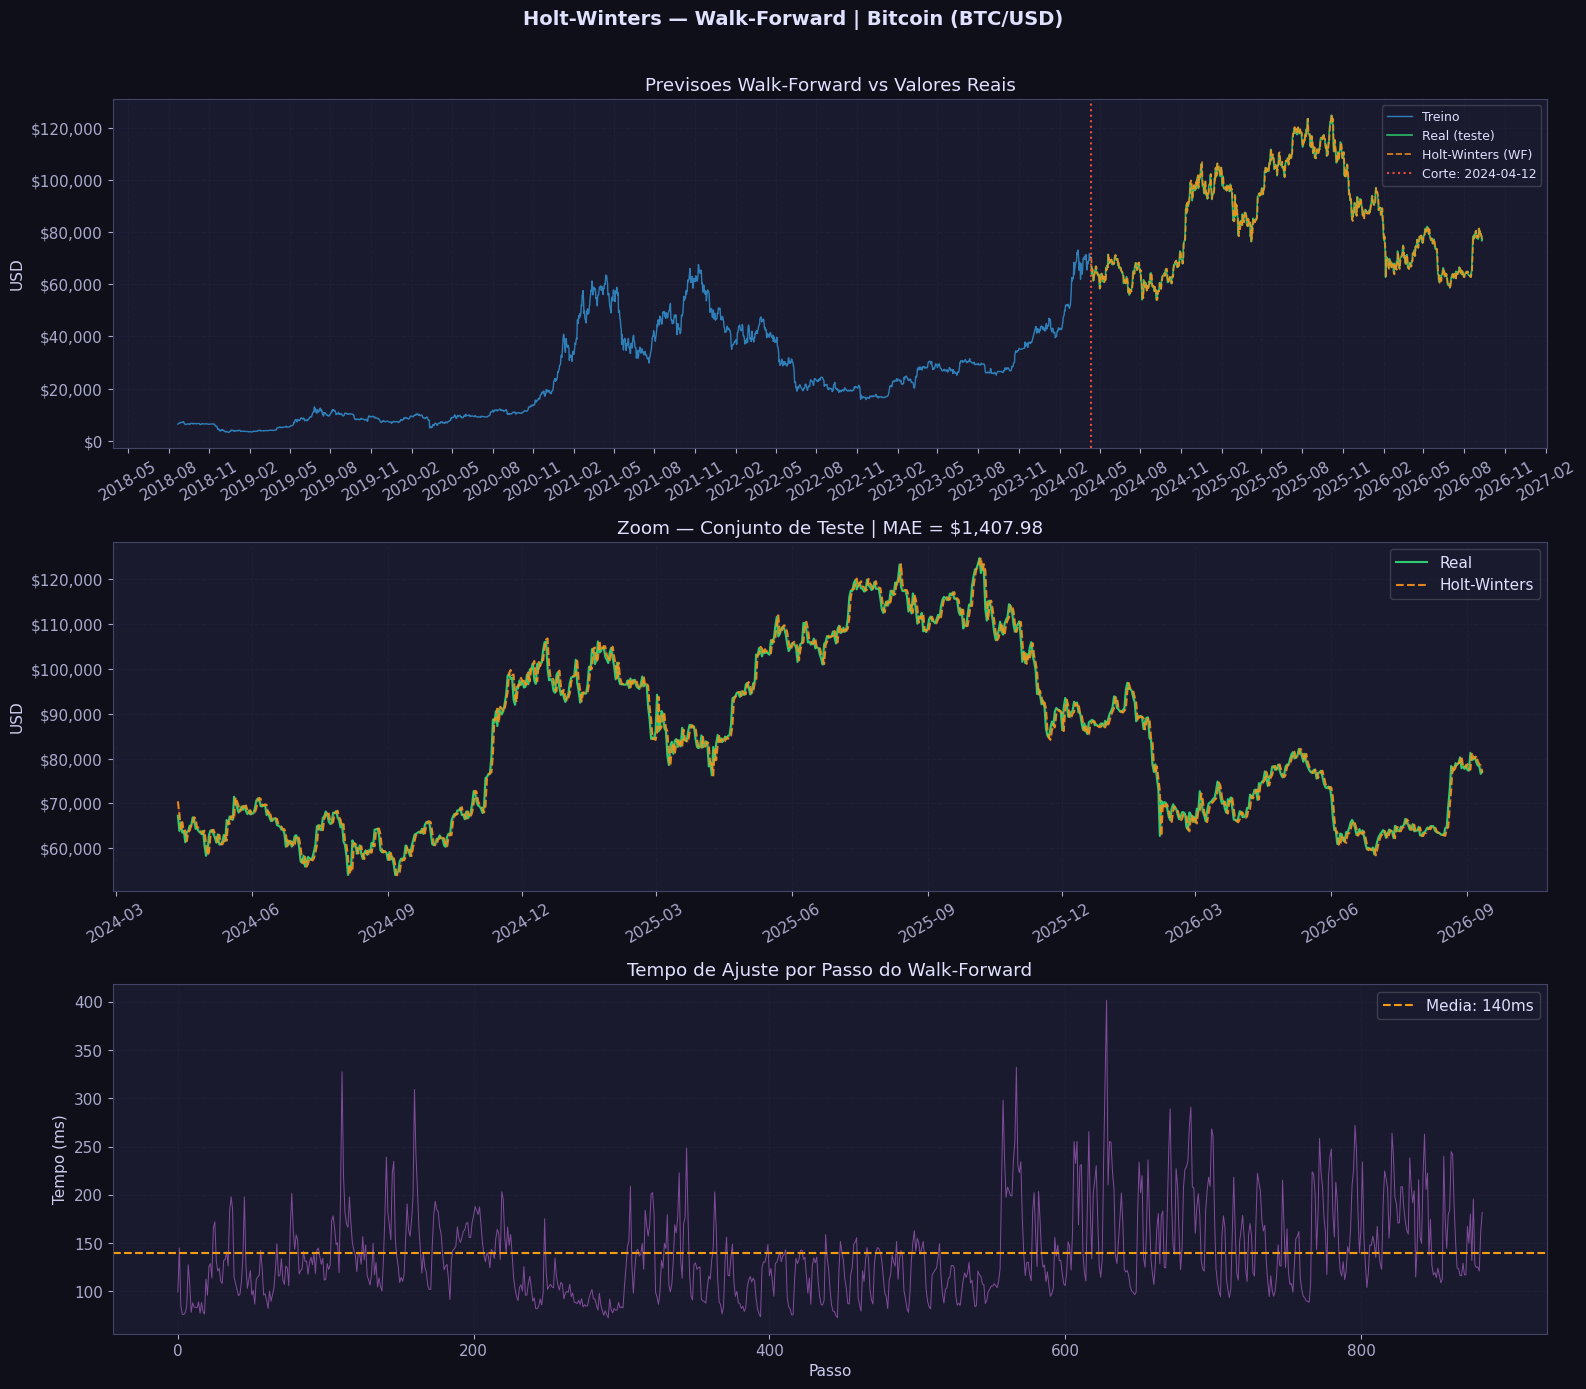

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor='#0f0f1a')
fig.suptitle('Holt-Winters — Walk-Forward | Bitcoin (BTC/USD)',
             color='#e0e0ff', fontsize=14, fontweight='bold', y=0.99)

# ── Painel 1: Série completa + previsões
ax1 = axes[0]
ax1.plot(serie_train.index, serie_train.values,
         color='#3498db', linewidth=1.0, alpha=0.8, label='Treino')
ax1.plot(pd.to_datetime(df_preds['date']), df_preds['y_real'],
         color='#2ecc71', linewidth=1.2, alpha=0.9, label='Real (teste)')
ax1.plot(pd.to_datetime(df_preds['date']), df_preds['y_pred'],
         color='#f7931a', linewidth=1.2, alpha=0.9, linestyle='--', label='Holt-Winters (WF)')
ax1.axvline(data_corte, color='#e74c3c', linestyle=':', linewidth=1.5,
            label=f'Corte: {data_corte.date()}')
ax1.set_title('Previsoes Walk-Forward vs Valores Reais', color='#e0e0ff')
ax1.set_ylabel('USD')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(framealpha=0.2, fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Painel 2: Zoom no conjunto de teste
ax2 = axes[1]
ax2.plot(pd.to_datetime(df_preds['date']), df_preds['y_real'],
         color='#2ecc71', linewidth=1.5, label='Real')
ax2.plot(pd.to_datetime(df_preds['date']), df_preds['y_pred'],
         color='#f7931a', linewidth=1.5, linestyle='--', label='Holt-Winters', alpha=0.9)
ax2.fill_between(pd.to_datetime(df_preds['date']),
                  df_preds['y_real'], df_preds['y_pred'],
                  alpha=0.15, color='#e74c3c')
ax2.set_title(f'Zoom — Conjunto de Teste | MAE = ${mae:,.2f}', color='#e0e0ff')
ax2.set_ylabel('USD')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend(framealpha=0.2)
ax2.grid(True, alpha=0.3)

# ── Painel 3: Tempo de ajuste por passo
ax3 = axes[2]
ax3.plot(range(len(tempos_fit)), [t*1000 for t in tempos_fit],
         color='#9b59b6', linewidth=0.7, alpha=0.8)
ax3.axhline(np.mean(tempos_fit)*1000, color='#f39c12', linestyle='--', linewidth=1.5,
            label=f'Media: {np.mean(tempos_fit)*1000:.0f}ms')
ax3.set_title('Tempo de Ajuste por Passo do Walk-Forward', color='#e0e0ff')
ax3.set_xlabel('Passo')
ax3.set_ylabel('Tempo (ms)')
ax3.legend(framealpha=0.2)
ax3.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(OUTPUT_DIR / 'plot_HW_03_walkforward.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Análise do Erro ao Longo do Tempo

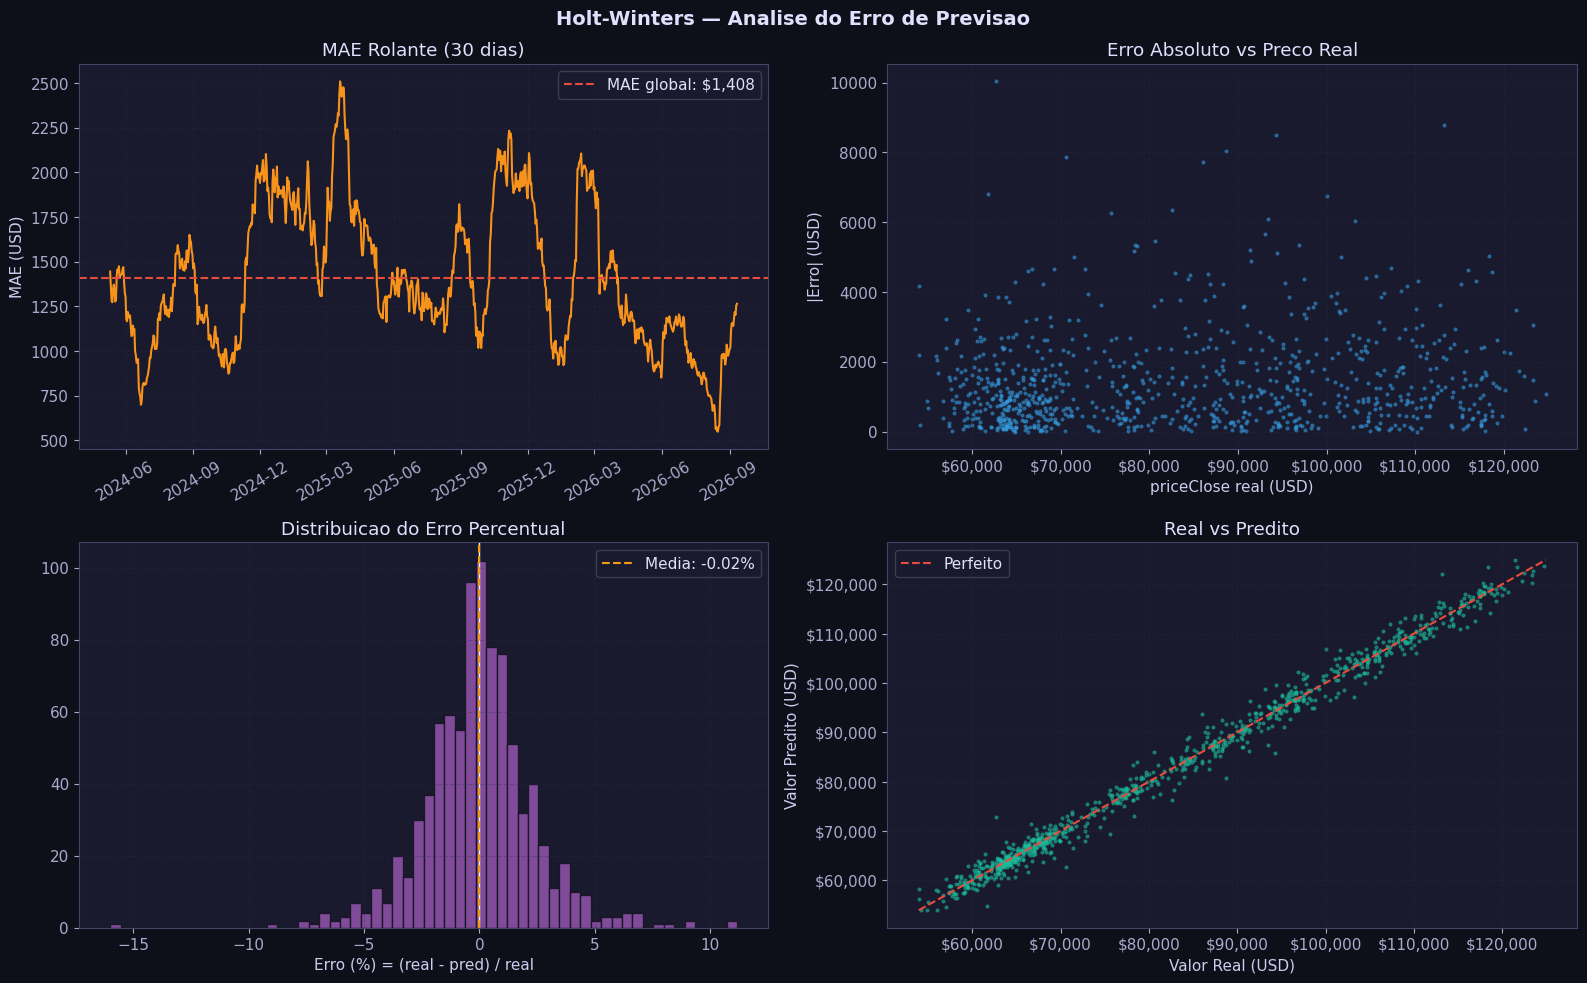

In [9]:
# MAE rolante (30 dias) para ver estabilidade
abs_erros = df_preds['residuo'].abs()
mae_rolling = abs_erros.rolling(30).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Holt-Winters — Analise do Erro de Previsao',
             color='#e0e0ff', fontsize=14, fontweight='bold')

# MAE rolling
axes[0,0].plot(pd.to_datetime(df_preds['date']), mae_rolling,
               color='#f7931a', linewidth=1.5)
axes[0,0].axhline(mae, color='#e74c3c', linestyle='--', linewidth=1.5,
                  label=f'MAE global: ${mae:,.0f}')
axes[0,0].set_title('MAE Rolante (30 dias)', color='#e0e0ff')
axes[0,0].set_ylabel('MAE (USD)')
axes[0,0].legend(framealpha=0.2)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0,0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30)

# Erro absoluto vs preço real
axes[0,1].scatter(df_preds['y_real'], abs_erros,
                  color='#3498db', s=4, alpha=0.5)
axes[0,1].set_title('Erro Absoluto vs Preco Real', color='#e0e0ff')
axes[0,1].set_xlabel('priceClose real (USD)')
axes[0,1].set_ylabel('|Erro| (USD)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0,1].grid(True, alpha=0.3)

# Histograma do erro percentual
erro_pct = (df_preds['residuo'] / df_preds['y_real']) * 100
axes[1,0].hist(erro_pct, bins=60, color='#9b59b6', alpha=0.8, edgecolor='#0f0f1a')
axes[1,0].axvline(0, color='#ffffff', linewidth=1)
axes[1,0].axvline(erro_pct.mean(), color='#f39c12', linestyle='--', linewidth=1.5,
                   label=f'Media: {erro_pct.mean():.2f}%')
axes[1,0].set_title('Distribuicao do Erro Percentual', color='#e0e0ff')
axes[1,0].set_xlabel('Erro (%) = (real - pred) / real')
axes[1,0].legend(framealpha=0.2)
axes[1,0].grid(True, alpha=0.3)

# Scatter: real vs predito
lims = [min(df_preds['y_real'].min(), df_preds['y_pred'].min()),
        max(df_preds['y_real'].max(), df_preds['y_pred'].max())]
axes[1,1].scatter(df_preds['y_real'], df_preds['y_pred'],
                  color='#1abc9c', s=4, alpha=0.5)
axes[1,1].plot(lims, lims, color='#e74c3c', linewidth=1.5, linestyle='--', label='Perfeito')
axes[1,1].set_title('Real vs Predito', color='#e0e0ff')
axes[1,1].set_xlabel('Valor Real (USD)')
axes[1,1].set_ylabel('Valor Predito (USD)')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,1].legend(framealpha=0.2)
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_HW_04_analise_erro.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Exportação das Previsões e Resíduos

In [10]:
# Exportar previsões
df_export = df_preds[['date', 'y_real', 'y_pred', 'residuo']].copy()
df_export.columns = ['date', 'priceClose_real', 'priceClose_pred_HW', 'residuo_HW']
df_export.to_csv(OUTPUT_DIR / 'hw_previsoes_walkforward.csv', index=False)

# Exportar métricas resumidas
metricas = {
    'modelo': 'Holt-Winters',
    'base': 'bitcoin',
    'alvo': 'priceClose',
    'protocolo': 'walk-forward 1-step-ahead expanding window',
    'n_previsoes': int(len(df_preds)),
    'data_inicio_teste': str(df_preds['date'].iloc[0]),
    'data_fim_teste': str(df_preds['date'].iloc[-1]),
    'MAE':  float(mae),
    'RMSE': float(rmse),
    'MAPE': float(mape),
    'Bias': float(bias),
    'Std_residuo': float(std_r),
    'tempo_total_s': float(np.sum(tempos_fit)),
    'tempo_medio_ms': float(np.mean(tempos_fit) * 1000),
    'config_usada': HW_PARAMS
}

with open(OUTPUT_DIR / 'hw_metricas_walkforward.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

print('Arquivos exportados:')
print('  hw_previsoes_walkforward.csv   — previsoes, reais e residuos')
print('  hw_metricas_walkforward.json   — metricas de desempenho')
print()
print('=== Resumo Final ===')
print(f'  MAE  : ${mae:,.2f}')
print(f'  RMSE : ${rmse:,.2f}')
print(f'  MAPE : {mape:.2f}%')
print(f'  Bias : ${bias:,.2f}')

Arquivos exportados:
  hw_previsoes_walkforward.csv   — previsoes, reais e residuos
  hw_metricas_walkforward.json   — metricas de desempenho

=== Resumo Final ===
  MAE  : $1,407.98
  RMSE : $1,960.64
  MAPE : 1.72%
  Bias : $-11.90


## 7. Discussão do Protocolo

| Aspecto | Decisão |
|---------|----------|
| **Tipo de janela** | Expanding (cresce a cada passo) — mais realista: mais dados sempre ajudam |
| **Horizonte** | 1 passo à frente (`h=1`) — previsão do dia seguinte |
| **Refitting** | A cada passo — parâmetros de suavização re-estimados por MLE |
| **Hiperparâmetros** | Fixos (selecionados no notebook 01) — sem re-otimização no teste |
| **Fallback** | Se o ajuste falhar: usar valor do último dia (naive forecast) |
| **Origem das previsões** | Todas as datas do conjunto de teste |

**Próximo passo:** `03_previsoes_residuos.ipynb`